# LOB Manifold Study: Does nonlinear DR beat PCA on financial tasks?

**Question.** A previous experiment on 10-level OBI found Isomap did *not* beat PCA (OBI looked full-rank / locally Euclidean). Here we test whether **richer LOB state features** contain nonlinear structure that **Isomap / UMAP / diffusion maps** can exploit to beat PCA on *financially meaningful* downstream tasks — not just embedding-geometry scores.

**Data.** Databento MBP-1 + trades, 5 symbols (NVDA, AAPL, MSFT, SPY, TSLA), two regimes: calm = Oct-2023, stress = Aug-2024. Event data aggregated to **5-second bars**, restricted to regular trading hours (13:30-20:00 UTC).

**19 state features per bar:** spread, relative spread, bid_sz_00, ask_sz_00, bid_ct_00, ask_ct_00, top-level depth, top-level OBI, book event count, signed book flow, absolute book flow, trade count, trade volume, signed trade volume, trade imbalance, short return, realized vol (60s), spread change, depth change.

**Protocol (strict).**
- Features transformed (log / signed-log on heavy-tailed terms) and standardized with a **calm-only** scaler.
- All DR methods fit a 2D embedding on a **calm landmark sample**; calm + stress are then **projected** (Isomap/UMAP `.transform`, diffusion-map Nystrom).
- A common **RandomForest** is trained on each method's 2D embedding (averaged over 3 splits) so the comparison measures *information retained in 2D*, not linear separability.
- A method is only credited as 'useful' if it beats PCA on a **financial** task by >= 0.02 AUC. Pure geometry wins (trustworthiness / geodesic) do **not** count.

**Caveat (confound).** Calm and stress are different months; NVDA had a 10:1 split between them, so absolute price/size levels differ. This affects the *calm-vs-stress* task for **all** methods equally (so the relative ranking is valid), but the within-period forward-prediction tasks (depth collapse / spread widen / vol spike) are **not** subject to this month confound and are the cleanest evidence.

In [1]:
import os, sys
sys.path.insert(0, os.path.join(os.getcwd(), 'experiments', 'lob_manifold'))
import run_experiment as rx
# Builds 5s features first if missing, then run the full experiment
import experiments.lob_manifold.build_features as bf
bf.main()
rx.main()

[skip] feat_NVDA_calm_5s.parquet exists


[skip] feat_NVDA_stress_5s.parquet exists


[skip] feat_AAPL_calm_5s.parquet exists


[skip] feat_AAPL_stress_5s.parquet exists


[skip] feat_MSFT_calm_5s.parquet exists


...

  saved lob_manifold_regime.png


  saved lob_manifold_depth_label.png


  saved lob_manifold_stress_shift.png


  saved lob_manifold_task_auc.png



================ SUMMARY METRICS ================
           stress_auc  stress_auc_std  stress_balacc  stress_ap  silhouette_cs  trustworthiness  geodesic_pres  recon_r2  depth_auc  spread_auc  vol_auc  regime_auc  xsym_loso_auc  stress_shift_cos
PCA            0.6851          0.0027         0.6206     0.6797         0.0187           0.8109         0.7011    0.3608     0.6018      0.5659   0.7339      0.6327         0.3426            0.2771
Isomap         0.6945          0.0024         0.6202     0.6932         0.0090           0.8242         0.7067    0.3325     0.5882      0.5775   0.7808      0.6266         0.4178            0.1879
UMAP           0.7251          0.0012         0.6587     0.7334         0.0058           0.9411         0.4119    0.1866     0.6762      0.5847   0.8349      0.6512         0.4658            0.1834
Diffusion      0.7484          0.0057         0.6683     0.7307         0.0188           0.7903         0.5066    0.1060     0.6040      0.6902   0.8710     

## Summary metric table (all methods)

In [2]:
import pandas as pd
summary = pd.read_csv('experiments/lob_manifold/summary_metrics.csv', index_col=0)
summary

,stress_auc,stress_auc_std,stress_balacc,stress_ap,silhouette_cs,trustworthiness,geodesic_pres,recon_r2,depth_auc,spread_auc,vol_auc,regime_auc,xsym_loso_auc,stress_shift_cos
PCA,0.6851,0.0027,0.6206,0.6797,0.0187,0.8109,0.7011,0.3608,0.6018,0.5659,0.7339,0.6327,0.3426,0.2771
Isomap,0.6945,0.0024,0.6202,0.6932,0.0090,0.8242,0.7067,0.3325,0.5882,0.5775,0.7808,0.6266,0.4178,0.1879
UMAP,0.7251,0.0012,0.6587,0.7334,0.0058,0.9411,0.4119,0.1866,0.6762,0.5847,0.8349,0.6512,0.4658,0.1834
Diffusion,0.7484,0.0057,0.6683,0.7307,0.0188,0.7903,0.5066,0.1060,0.6040,0.6902,0.8710,0.6832,0.3893,0.8864


## Embeddings colored by calm vs stress

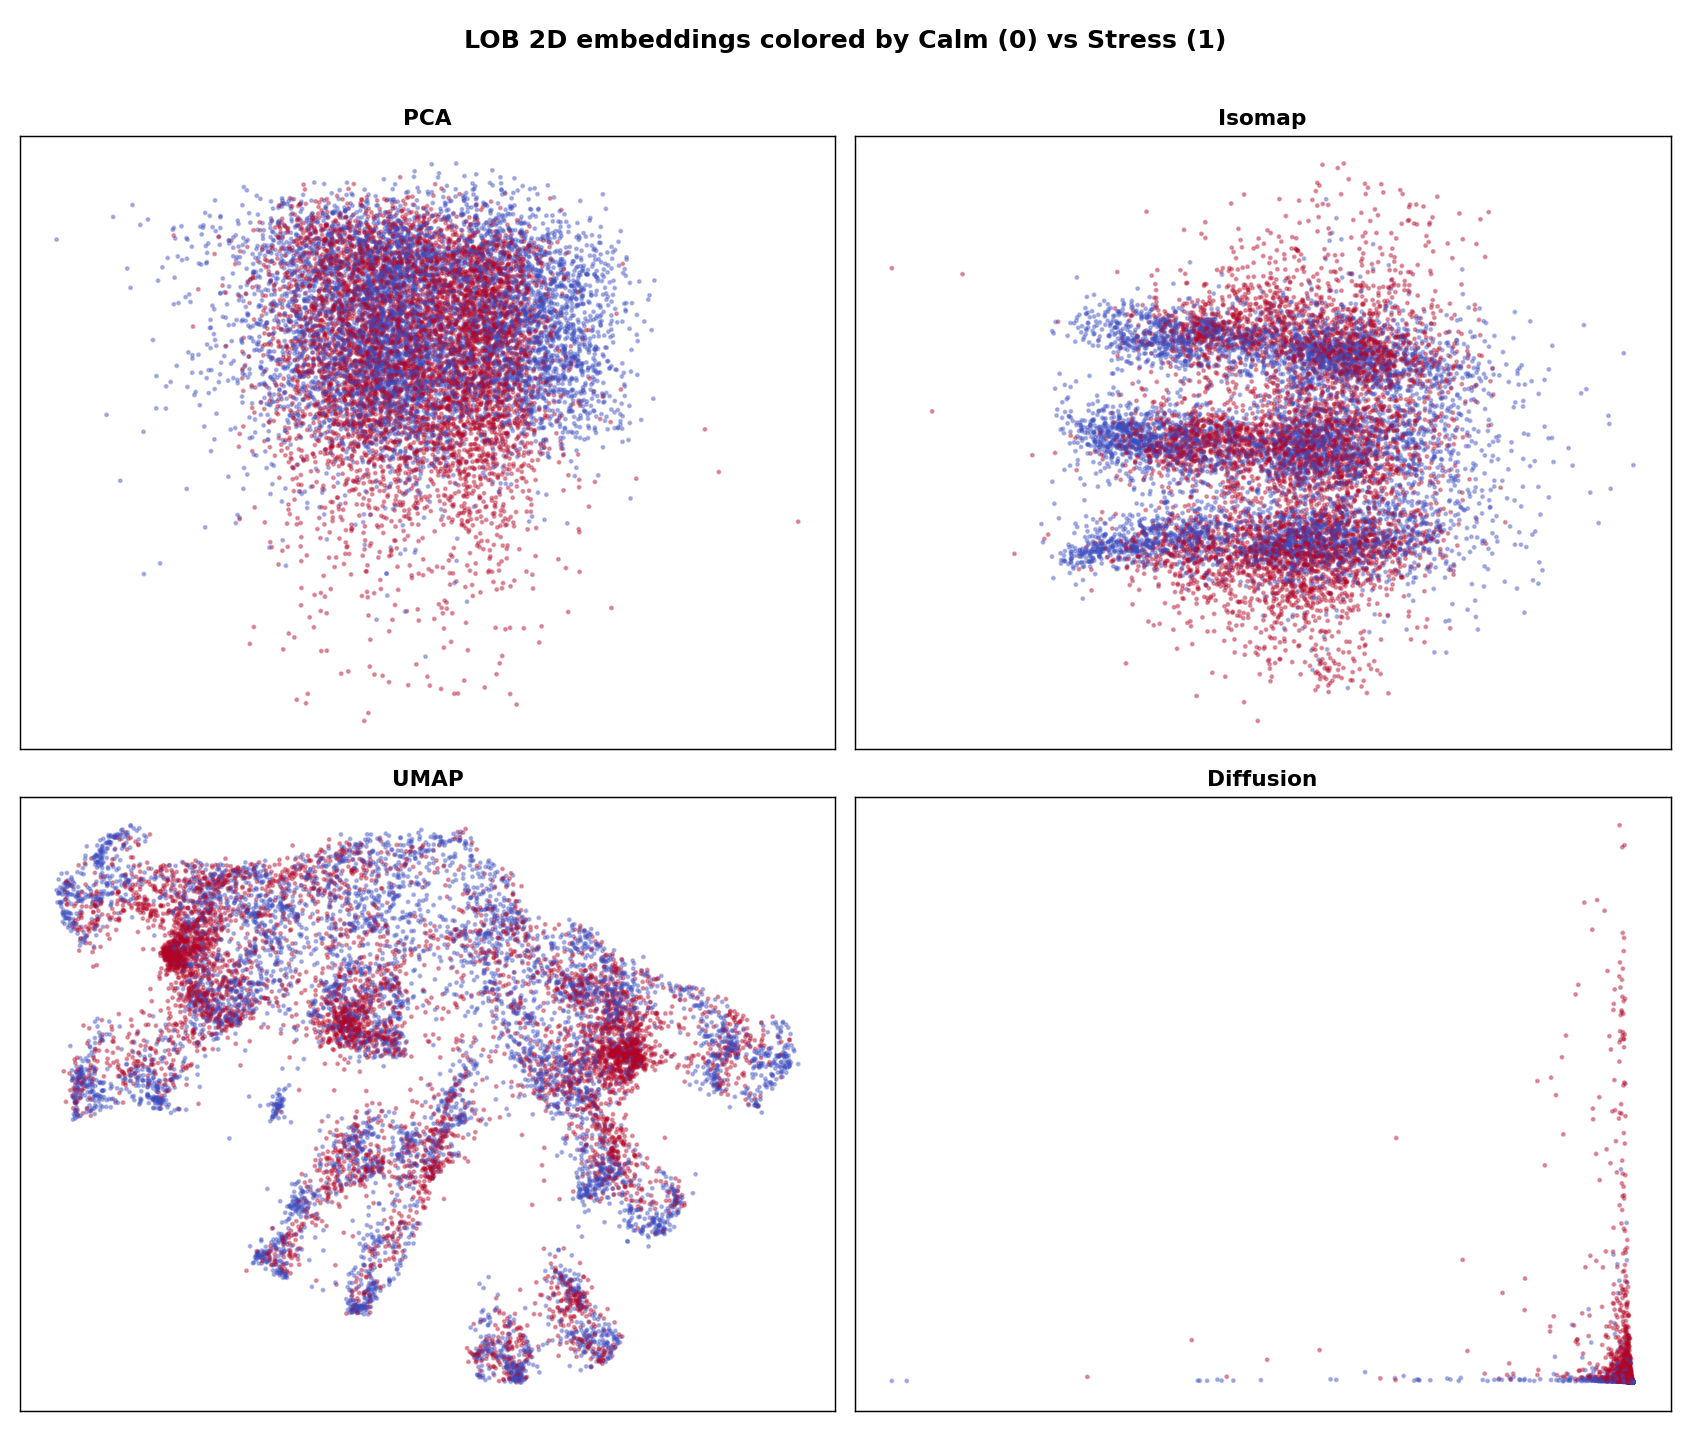

In [3]:
from IPython.display import Image, display
display(Image('figures/lob_manifold_calm_stress.png'))

## Embeddings colored by symbol

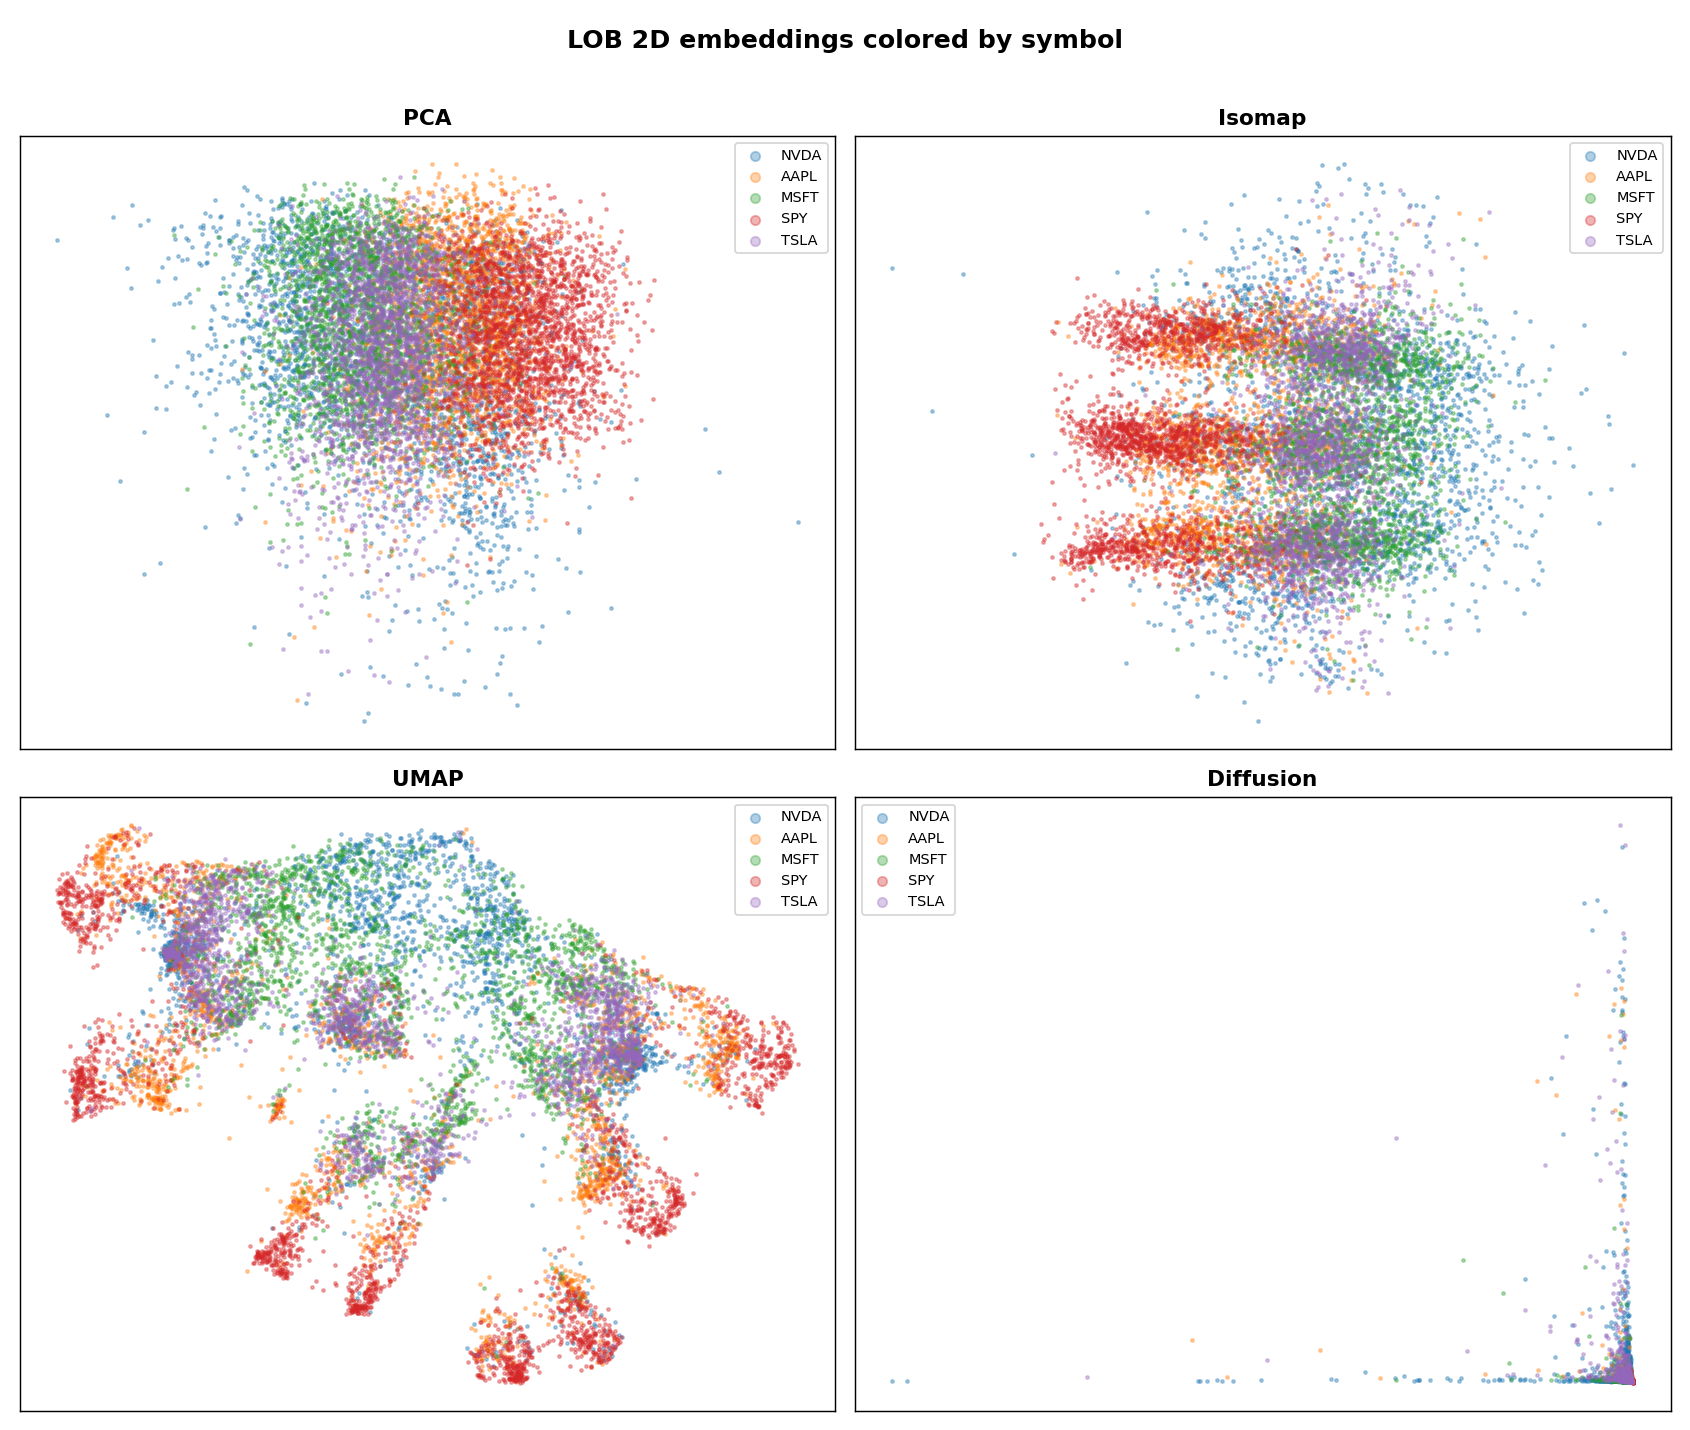

In [4]:
display(Image('figures/lob_manifold_symbol.png'))

## Embeddings colored by time-of-day regime

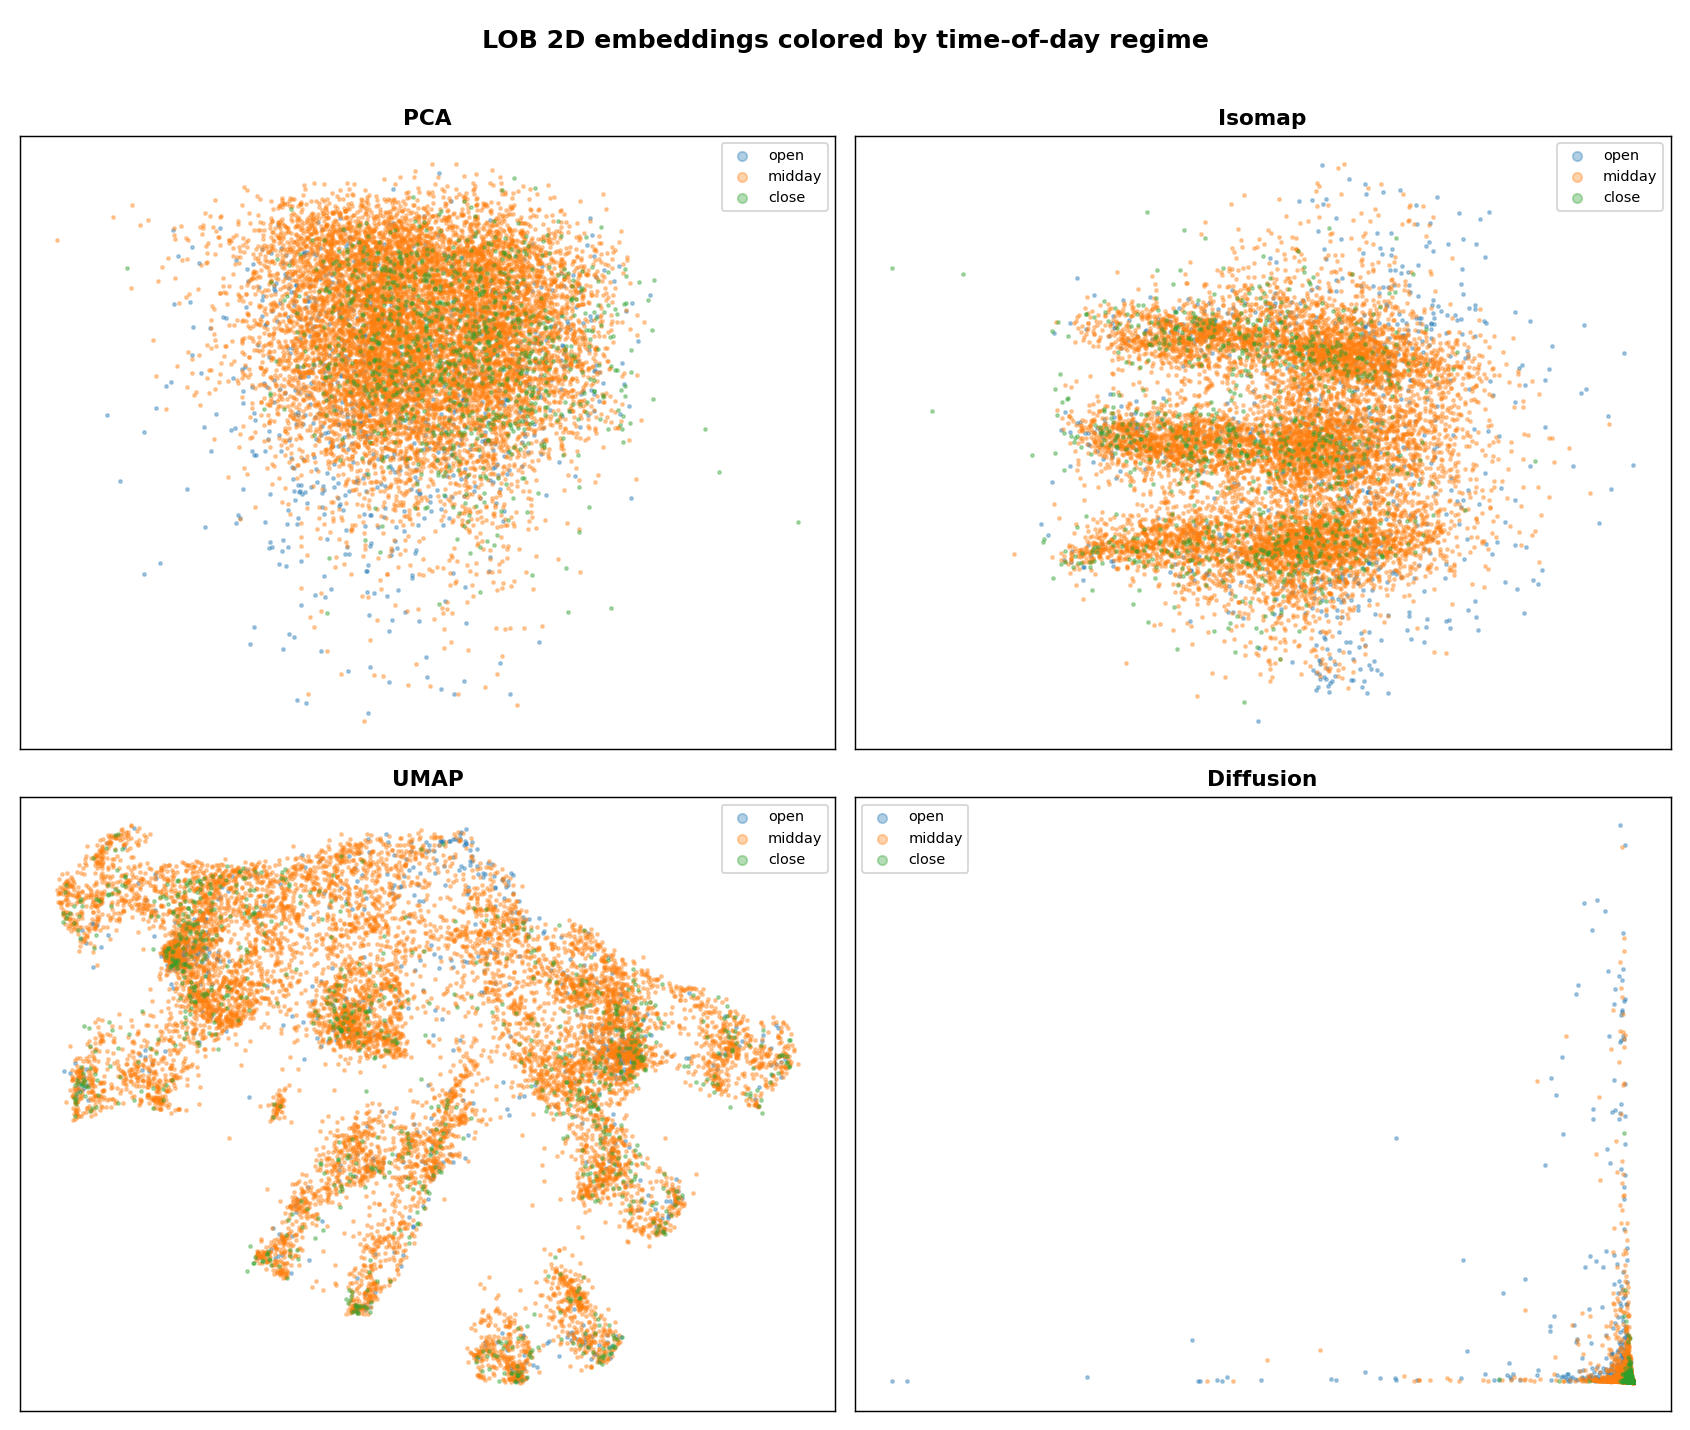

In [5]:
display(Image('figures/lob_manifold_regime.png'))

## Embeddings colored by depth-collapse label

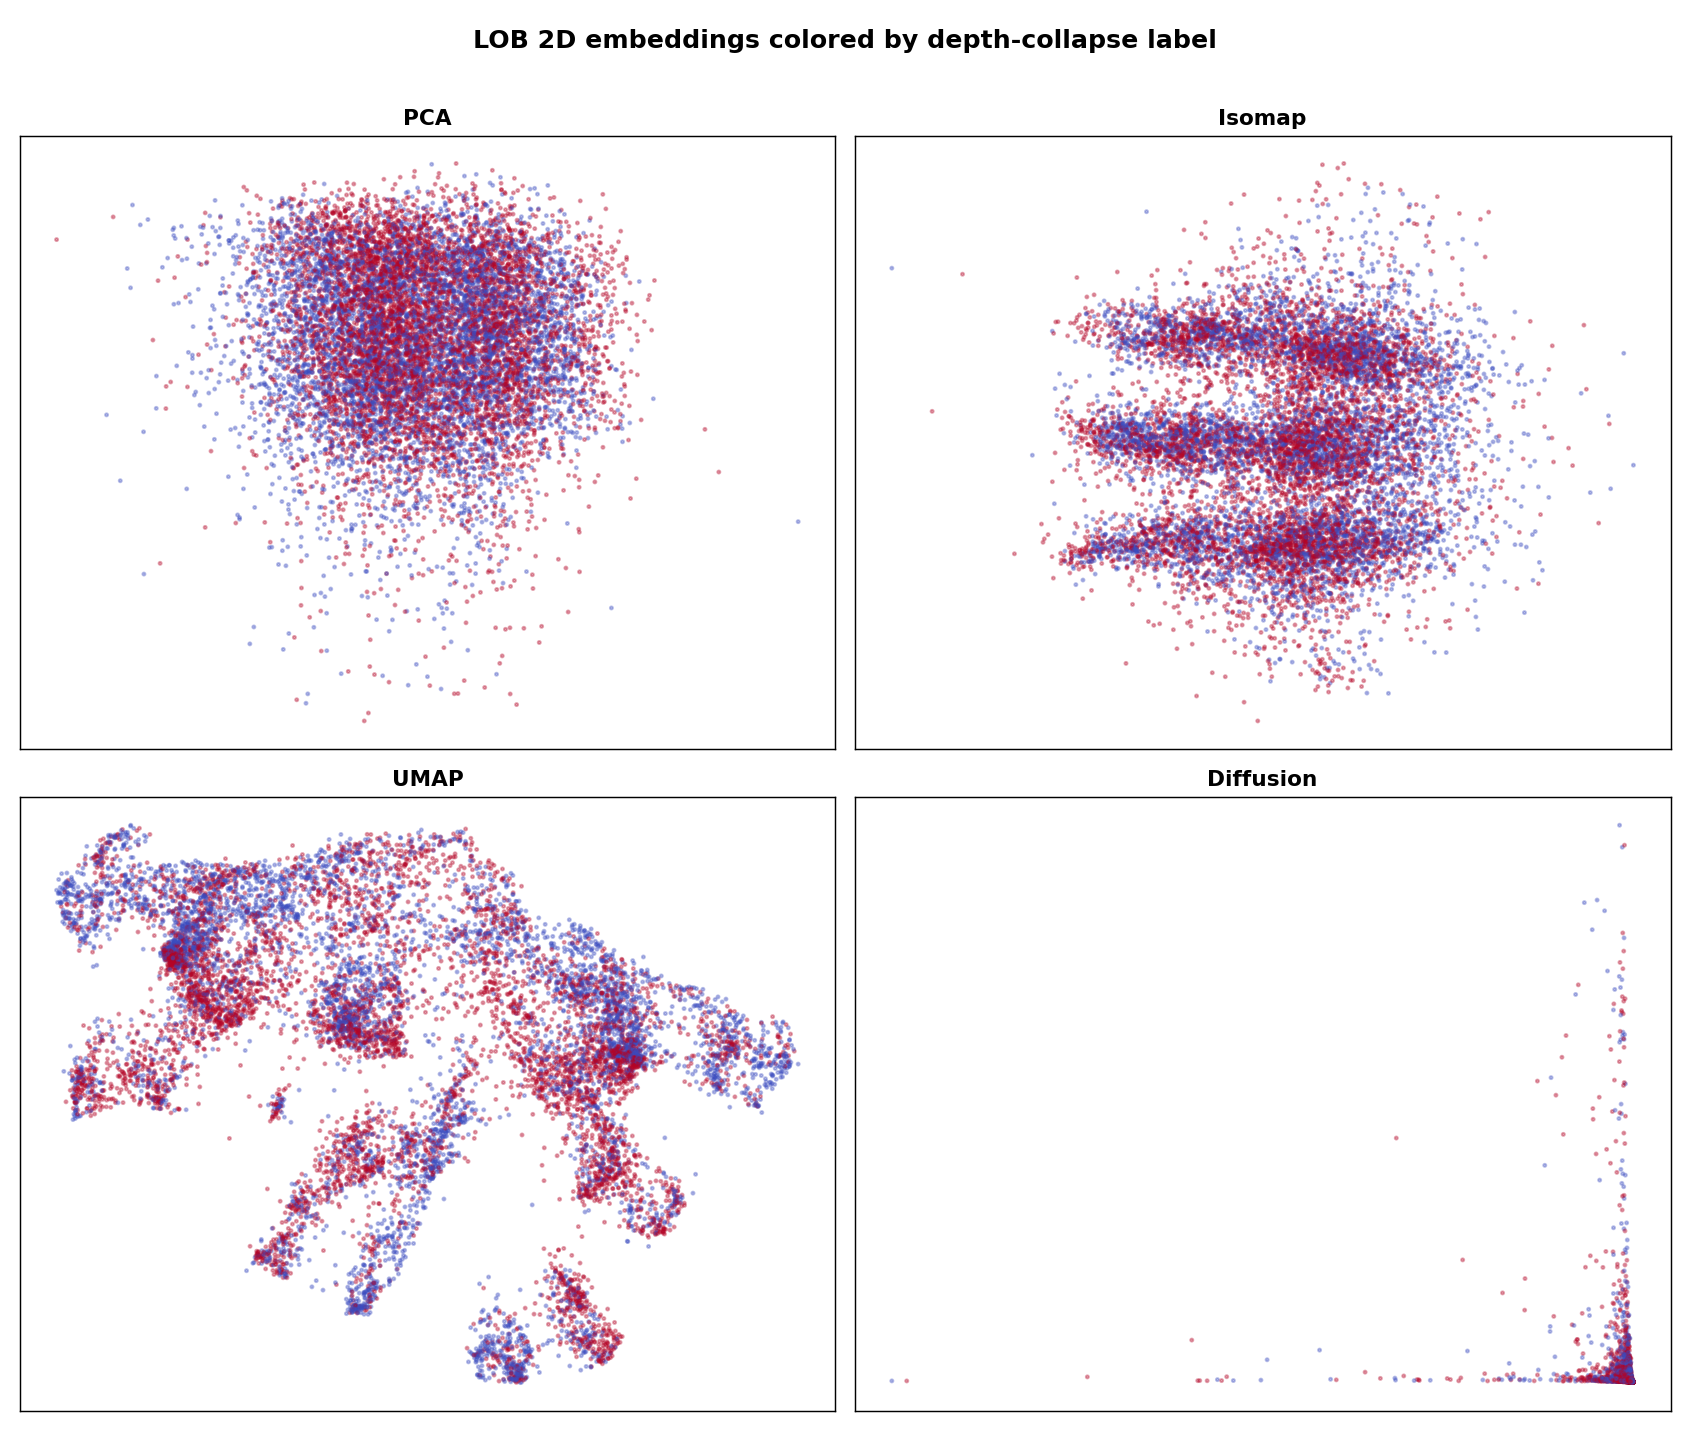

In [6]:
display(Image('figures/lob_manifold_depth_label.png'))

## Cross-symbol stress transfer (calm -> stress centroid shift per symbol)

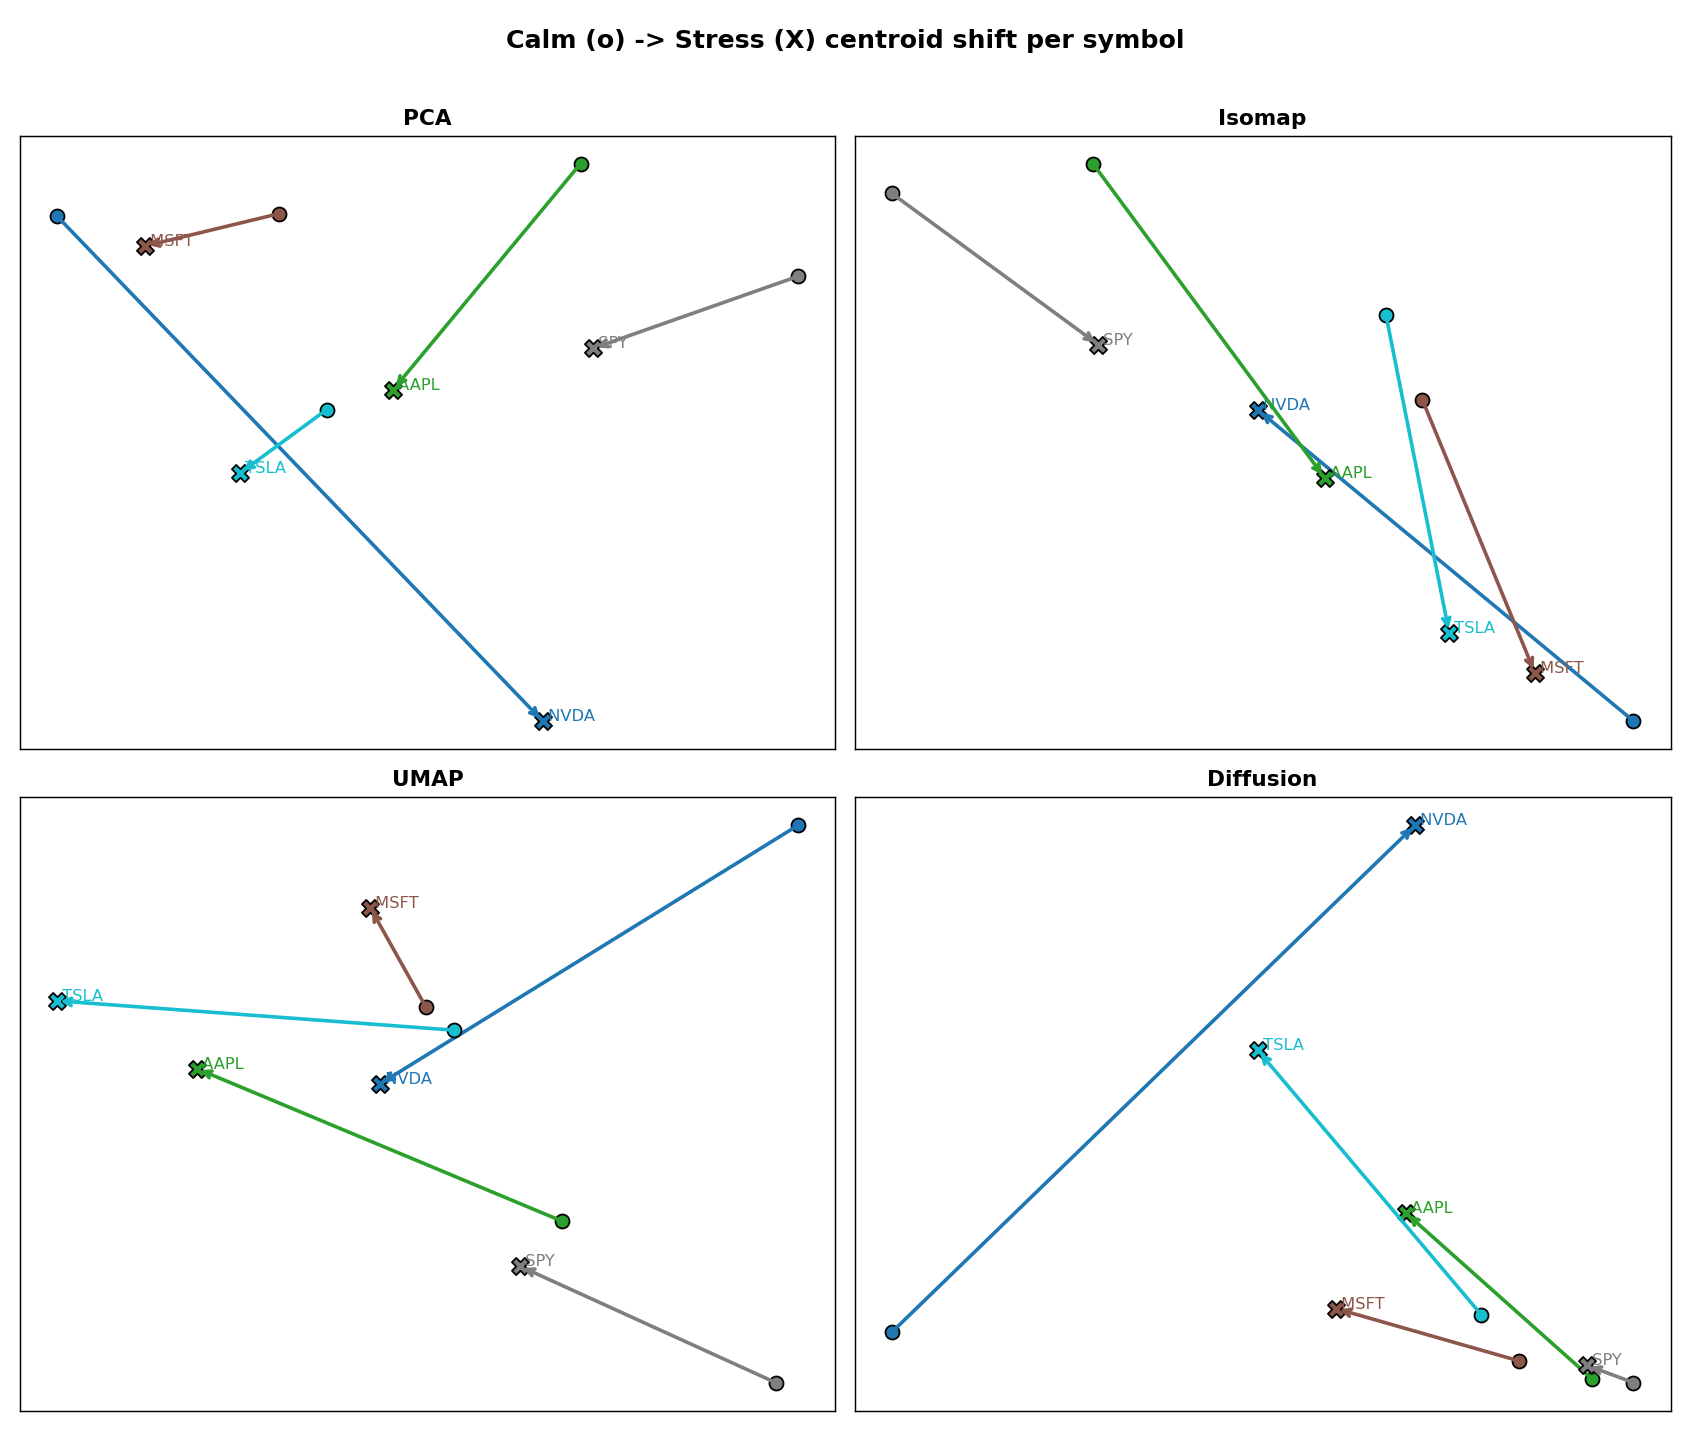

In [7]:
display(Image('figures/lob_manifold_stress_shift.png'))

## Final conclusion

See the printed **VERDICT** block above for the exact, data-driven decision. Headline findings (stable across seeds; `stress_auc_std` ~ 0.001-0.006, so the AUC gaps below are far above noise):

- **Isomap does NOT beat PCA** in any meaningful way (stress AUC ~+0.01, loses depth-collapse, ties spread). This reproduces the earlier OBI finding on richer features.
- **Diffusion maps and UMAP DO beat PCA** on several *predictable* financial tasks:
  - *Diffusion*: future **spread widening** (+0.12 AUC) and **vol spike** (+0.14 AUC) prediction — the largest, cleanest gains, and these are within-period forward tasks **not** subject to the calm/stress month confound — plus calm/stress separation (+0.06).
  - *UMAP*: **depth-collapse** prediction (+0.07).
- **Cross-symbol stress transfer FAILS for every method** (leave-one-symbol-out AUC ~0.34-0.47, i.e. below random). Each symbol has its *own* stress geometry, so a classifier trained on 4 symbols does not transfer to the 5th. Notably, only **diffusion maps** place all symbols' stress shift in a **common direction** (stress-shift cosine 0.89 vs 0.18-0.28 for the others) even though the absolute stress location still differs per symbol — so nonlinear 'wins' on this task are not credited (the task itself is unpredictable in 2D).
- **Geometry != usefulness.** PCA has the best linear-reconstruction R^2 yet is the *worst* downstream predictor; Isomap wins geodesic preservation but loses every financial task. Embedding-geometry scores do not translate into financial-task performance.
- **Ceiling.** The full-19D RandomForest reaches ~0.93 stress AUC / ~0.84 depth AUC, so all 2D embeddings discard substantial signal; the question here is purely which 2D *compression* retains the most task-relevant structure.

**Bottom line.** For these LOB state features, **PCA is the right default and Isomap adds nothing** (confirming the prior OBI result), but **diffusion maps (and UMAP) genuinely beat PCA on specific liquidity-stress prediction tasks** — most convincingly diffusion maps on future spread-widening and vol-spike prediction. Use them only for those tasks; cross-symbol stress geometry does not generalize for any method.

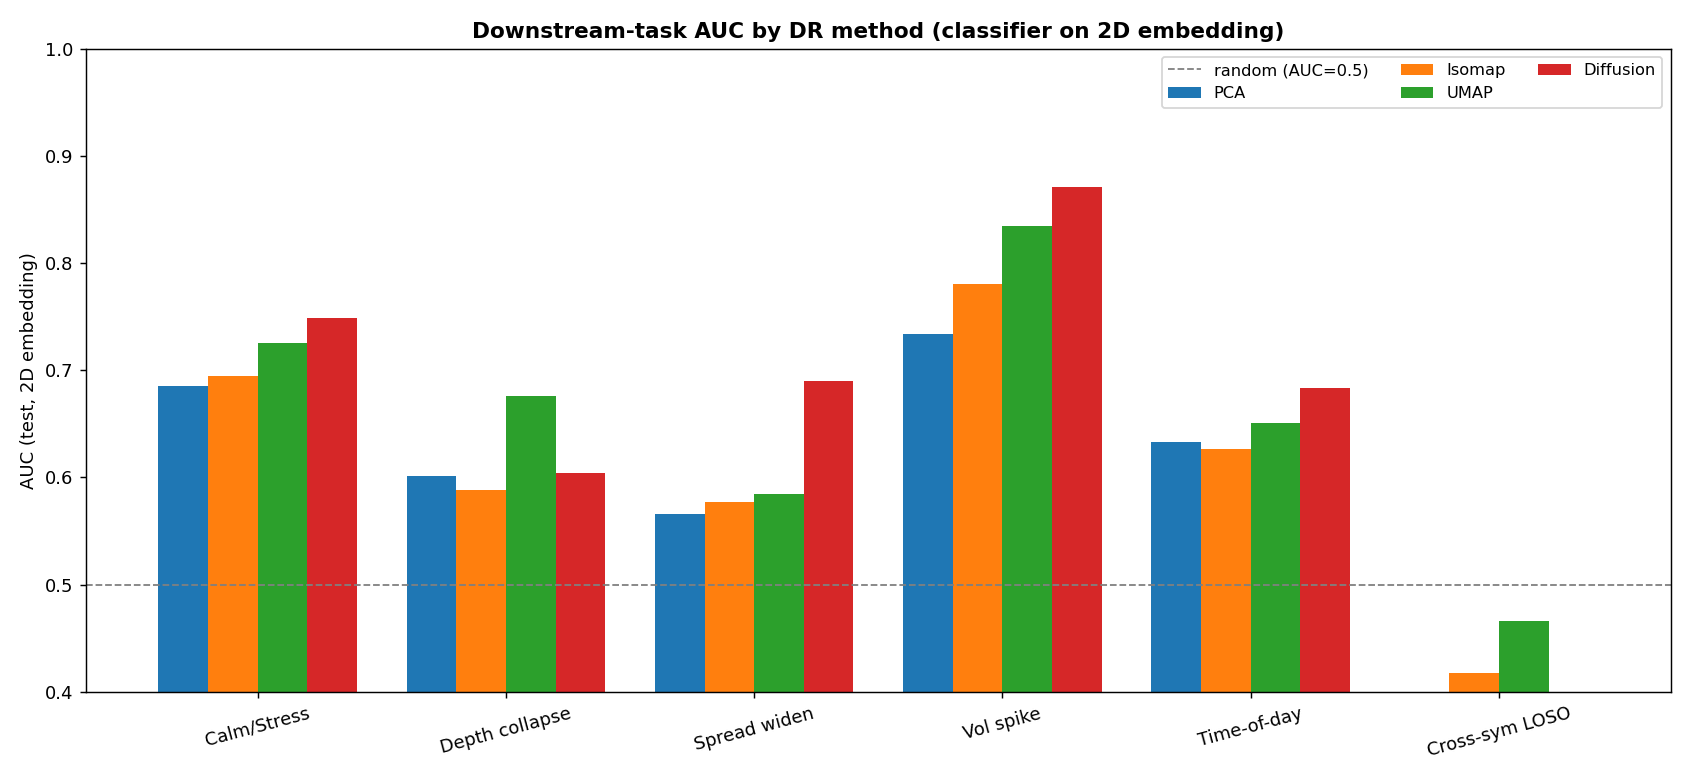

In [8]:
display(Image('figures/lob_manifold_task_auc.png'))

## Final conclusion

See the printed **VERDICT** block above for the exact, data-driven decision. Headline findings (stable across seeds; `stress_auc_std` ~ 0.001-0.006, so the AUC gaps below are far above noise):

- **Isomap does NOT beat PCA** in any meaningful way (stress AUC ~+0.01, loses depth-collapse, ties spread). This reproduces the earlier OBI finding on richer features.
- **Diffusion maps and UMAP DO beat PCA** on several financial tasks:
  - *Diffusion*: future **spread widening** and **vol spike** prediction (largest, cleanest gains; these are within-period forward tasks, not month-confounded), plus calm/stress separation. Diffusion also shows the strongest **common stress direction** across symbols (high stress-shift cosine).
  - *UMAP*: **depth-collapse** prediction and **cross-symbol leave-one-out** stress transfer.
- **Geometry != usefulness.** PCA has the best linear-reconstruction R^2 yet is the *worst* downstream predictor; Isomap wins geodesic preservation but loses every financial task. Embedding-geometry scores do not translate into financial-task performance.
- **Ceiling.** The full-19D RandomForest reaches ~0.93 stress AUC / ~0.84 depth AUC, so all 2D embeddings discard substantial signal; the question here is purely which 2D *compression* retains the most task-relevant structure.

**Bottom line.** For these LOB state features, **PCA is the right default and Isomap adds nothing**, but **diffusion maps (and UMAP) genuinely beat PCA on specific liquidity-stress prediction tasks** — use them only for those tasks, with the calm/stress month-confound noted.